In [1]:
#시계열 : 시간 상의 여러 지점을 관측하거나 측정할 수 있는 모든 것
#대부분의 시계열은 고정빈도(fixed frequency)로 표현/불규칙적인 모습으로 표현
from datetime import datetime
now = datetime.now()
now

datetime.datetime(2021, 5, 7, 15, 39, 41, 648121)

In [2]:
now.year, now.month, now.day

(2021, 5, 7)

In [3]:
delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15)
delta #두 객체간의 시간적인 차이

datetime.timedelta(days=926, seconds=56700)

In [4]:
from datetime import timedelta

start = datetime(2011, 1, 7)
start + timedelta(12) #timedelta : 더하거나 빼면 그만큼의 시간이 datetime 객체에 적용

datetime.datetime(2011, 1, 19, 0, 0)

In [5]:
start - 2*timedelta(12)

datetime.datetime(2010, 12, 14, 0, 0)

In [6]:
stamp = datetime(2011, 1, 3)

str(stamp)

'2011-01-03 00:00:00'

In [7]:
stamp.strftime('%Y-%m-%d') # 날짜 -> 문자열

'2011-01-03'

In [8]:
value = '2011-01-03'
datetime.strptime(value, '%Y-%m-%d') #문자열 -> 날짜

datetime.datetime(2011, 1, 3, 0, 0)

In [9]:
datestrs = ['7/6/2011', '8/6/2011']

[datetime.strptime(x, '%m/%d/%Y') for x in datestrs]
#datetime.strptime : 알려진 형식의 날짜를 파싱하는 최적의 방법

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

In [10]:
from dateutil.parser import parse

parse('2011-01-03')

datetime.datetime(2011, 1, 3, 0, 0)

In [11]:
parse('Jan 31, 1997 10:45PM') #dateutil은 거의 대부분의 사람이 인지하는 날짜 표현 방식을 파싱

datetime.datetime(1997, 1, 31, 22, 45)

In [12]:
parse('6/12/2011', dayfirst = True) #날짜가 월 앞에 오는 경우 

datetime.datetime(2011, 12, 6, 0, 0)

In [13]:
import pandas as pd
import numpy as np
from pandas import Series, DataFrame

datestrs = ['2011-07-06 12:00:00', '2011-08-06 00:00:00']

pd.to_datetime(datestrs) #to_datetime : 많은 종류의 날짜 표현을 처리

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

In [14]:
idx = pd.to_datetime(datestrs + [None]) #누락된 값으로 간주되어야 할 값도 처리
idx #NaT : pandas에서 누락된 타임스탬프 데이터를 나타냄

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)

In [15]:
pd.isnull(idx)

array([False, False,  True])

In [16]:
from datetime import datetime

dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
        datetime(2011, 1, 7), datetime(2011, 1, 8),
        datetime(2011, 1, 10), datetime(2011, 1, 12)]
ts = pd.Series(np.random.randn(6), index = dates)
ts

2011-01-02   -0.901187
2011-01-05   -0.140647
2011-01-07    0.903226
2011-01-08    0.009922
2011-01-10    1.102532
2011-01-12   -0.266036
dtype: float64

In [17]:
ts.index #datetime 객체는 DatetimeIndex에 들어있으며, ts 변수의 타입은 TimeSeries

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

In [18]:
 #서로 다르게 인덱스 된 시계열 객체 간의 산술 연산은 자동으로 날짜에 맞춰짐
 ts + ts[::2]

2011-01-02   -1.802375
2011-01-05         NaN
2011-01-07    1.806452
2011-01-08         NaN
2011-01-10    2.205064
2011-01-12         NaN
dtype: float64

In [19]:
ts.index.dtype

dtype('<M8[ns]')

In [20]:
stamp = ts.index[0] #DatetimeIndex의 스칼라값은 pandas의 Timestamp 객체
stamp

Timestamp('2011-01-02 00:00:00')

In [21]:
ts

2011-01-02   -0.901187
2011-01-05   -0.140647
2011-01-07    0.903226
2011-01-08    0.009922
2011-01-10    1.102532
2011-01-12   -0.266036
dtype: float64

In [22]:
stamp = ts.index[2]
ts[stamp] #시계열은 라벨에 기반해서 데이터를 선택하고 인덱싱할 때 pd.Series와 동일하게 동작

0.9032261407436734

In [23]:
ts['1/10/2011']

1.1025319274641912

In [24]:
ts['20110110']

1.1025319274641912

In [25]:
longer_ts = pd.Series(np.random.randn(1000),
                        index = pd.date_range('1/1/2000', periods= 1000))
longer_ts

2000-01-01    2.367030
2000-01-02   -1.235623
2000-01-03   -1.118547
2000-01-04   -1.356036
2000-01-05    1.028285
                ...   
2002-09-22    1.198099
2002-09-23    0.401959
2002-09-24   -0.850237
2002-09-25   -1.110957
2002-09-26    1.268819
Freq: D, Length: 1000, dtype: float64

In [26]:
longer_ts['2001']

2001-01-01   -0.805580
2001-01-02   -0.959155
2001-01-03    1.088135
2001-01-04    1.333403
2001-01-05    0.549571
                ...   
2001-12-27    0.350495
2001-12-28   -2.134100
2001-12-29    0.454402
2001-12-30    0.764542
2001-12-31   -0.752642
Freq: D, Length: 365, dtype: float64

In [27]:
longer_ts['2001-05']

2001-05-01   -0.137318
2001-05-02    0.399938
2001-05-03    0.247820
2001-05-04    0.103113
2001-05-05   -0.327677
2001-05-06    1.977913
2001-05-07    0.024761
2001-05-08   -1.824632
2001-05-09   -0.265283
2001-05-10   -0.049251
2001-05-11   -0.767652
2001-05-12   -0.187866
2001-05-13   -1.202179
2001-05-14    0.956630
2001-05-15    0.681528
2001-05-16    0.555654
2001-05-17   -0.494344
2001-05-18   -1.022336
2001-05-19   -0.572630
2001-05-20   -0.737719
2001-05-21   -0.525710
2001-05-22    0.670757
2001-05-23    0.188982
2001-05-24   -0.692004
2001-05-25    1.560222
2001-05-26    0.339167
2001-05-27   -1.006146
2001-05-28    0.571237
2001-05-29   -0.516053
2001-05-30    0.868874
2001-05-31    0.021176
Freq: D, dtype: float64

In [28]:
#datetime 객체로 데이터를 잘라내는 작업도 일반적인 Series와 동일한 방식
ts[datetime(2011, 1, 7) : ]

2011-01-07    0.903226
2011-01-08    0.009922
2011-01-10    1.102532
2011-01-12   -0.266036
dtype: float64

In [29]:
ts['1/6/2011' : '1/11/2011'] #시계열에 포함되지 않고 타임스탬프를 이용해서 Series를 나눌 수 있음

2011-01-07    0.903226
2011-01-08    0.009922
2011-01-10    1.102532
dtype: float64

In [30]:
ts.truncate(after= '1/9/2011')

2011-01-02   -0.901187
2011-01-05   -0.140647
2011-01-07    0.903226
2011-01-08    0.009922
dtype: float64

In [31]:
dates = pd.date_range('1/1/2000', periods= 100, freq = 'W-WED')

long_df = pd.DataFrame(np.random.randn(100, 4),
                        index = dates,
                        columns = ['Colorado', 'Texas', 'New York', 'Ohio'])

In [32]:
dates

DatetimeIndex(['2000-01-05', '2000-01-12', '2000-01-19', '2000-01-26',
               '2000-02-02', '2000-02-09', '2000-02-16', '2000-02-23',
               '2000-03-01', '2000-03-08', '2000-03-15', '2000-03-22',
               '2000-03-29', '2000-04-05', '2000-04-12', '2000-04-19',
               '2000-04-26', '2000-05-03', '2000-05-10', '2000-05-17',
               '2000-05-24', '2000-05-31', '2000-06-07', '2000-06-14',
               '2000-06-21', '2000-06-28', '2000-07-05', '2000-07-12',
               '2000-07-19', '2000-07-26', '2000-08-02', '2000-08-09',
               '2000-08-16', '2000-08-23', '2000-08-30', '2000-09-06',
               '2000-09-13', '2000-09-20', '2000-09-27', '2000-10-04',
               '2000-10-11', '2000-10-18', '2000-10-25', '2000-11-01',
               '2000-11-08', '2000-11-15', '2000-11-22', '2000-11-29',
               '2000-12-06', '2000-12-13', '2000-12-20', '2000-12-27',
               '2001-01-03', '2001-01-10', '2001-01-17', '2001-01-24',
      

In [33]:
long_df

,Colorado,Texas,New York,Ohio
2000-01-05,-1.223562,-0.266743,-0.270167,-0.673889
2000-01-12,1.079886,0.297815,-0.068369,0.422063
2000-01-19,1.111930,0.031458,0.611952,0.657536
2000-01-26,0.059711,0.064176,-0.940303,0.117433
2000-02-02,1.444014,0.980272,-2.354307,-1.345581
...,...,...,...,...
2001-10-31,-0.659833,-1.332141,0.634065,0.590699
2001-11-07,0.205479,-1.593462,-1.670979,-0.041095
2001-11-14,1.274097,0.570526,-1.941440,2.066227
2001-11-21,-0.654187,-0.194836,0.809700,0.953143


In [34]:
long_df.loc['5-2001']

,Colorado,Texas,New York,Ohio
2001-05-02,-0.951873,0.100600,0.365606,-0.790707
2001-05-09,-1.256441,0.685405,-0.167171,-0.201902
2001-05-16,0.130635,-1.541317,-0.624853,-1.292670
2001-05-23,2.681730,-0.010341,0.628339,0.427813
2001-05-30,0.164040,0.370341,0.928460,1.579592


In [35]:
dates = pd.DatetimeIndex(['1/1/2000', '1/2/2000', '1/2/2000', '1/2/2000', '1/3/2000'])
dup_ts = pd.Series(np.arange(5), index = dates)
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int32

In [36]:
dup_ts.index.is_unique

False

In [37]:
dup_ts['1/3/2000']

4

In [38]:
dup_ts['1/2/2000']

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int32

In [39]:
#중복된 타임스탬프를 가지는 데이터 집계 -> groupby에 level = 0 (단일 단계 인덱싱)
grouped = dup_ts.groupby(level= 0)
grouped.mean()

2000-01-01    0
2000-01-02    2
2000-01-03    4
dtype: int32

In [40]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

In [41]:
#날짜 범위 생성하기 
#date_range : 일별 타임스탬프를 생성
index = pd.date_range('2012-04-01', '2012-06-01')
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

In [42]:
pd.date_range(start = '2012-04-01', periods = 20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[ns]', freq='D')

In [43]:
pd.date_range(end = '2012-06-01', periods = 20)

DatetimeIndex(['2012-05-13', '2012-05-14', '2012-05-15', '2012-05-16',
               '2012-05-17', '2012-05-18', '2012-05-19', '2012-05-20',
               '2012-05-21', '2012-05-22', '2012-05-23', '2012-05-24',
               '2012-05-25', '2012-05-26', '2012-05-27', '2012-05-28',
               '2012-05-29', '2012-05-30', '2012-05-31', '2012-06-01'],
              dtype='datetime64[ns]', freq='D')

In [44]:
pd.date_range('2000-01-01', '2000-12-01', freq= 'BM') # BM : 월 영업 마감일

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BM')

In [45]:
pd.date_range('2012-05-02 12:56:31', periods = 5) #시작시간이나 종료 시간의 타임 스탬프를 보존

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

In [46]:
pd.date_range('2012-05-02 12:56:31', periods= 5, normalize=True) #타임스탬프를 정규화

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

In [47]:
from pandas.tseries.offsets import Hour, Minute

hour = Hour()
hour

<Hour>

In [48]:
four_hours = Hour(4)
four_hours

<4 * Hours>

In [49]:
pd.date_range('2000-01-01', '2000-01-03 23:59', freq= '4h')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4H')

In [50]:
Hour(2) + Minute(30)

<150 * Minutes>

In [51]:
pd.date_range('2000-01-01', periods=10, freq= '1h30min')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90T')

In [52]:
#월별 주차
rng = pd.date_range('2012-01-01', '2012-09-01', freq='WOM-3FRI')
list(rng)

[Timestamp('2012-01-20 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-02-17 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-03-16 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-04-20 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-05-18 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-06-15 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-07-20 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-08-17 00:00:00', freq='WOM-3FRI')]

In [53]:
ts = pd.Series(np.random.randn(4),
                index = pd.date_range('1/1/2000', periods=4, freq = 'M'))
ts

2000-01-31   -0.096354
2000-02-29    0.994274
2000-03-31    0.590711
2000-04-30   -0.721293
Freq: M, dtype: float64

In [54]:
ts.shift(2) # 시간 축을 뒤로 이동

2000-01-31         NaN
2000-02-29         NaN
2000-03-31   -0.096354
2000-04-30    0.994274
Freq: M, dtype: float64

In [55]:
ts.shift(-2)

2000-01-31    0.590711
2000-02-29   -0.721293
2000-03-31         NaN
2000-04-30         NaN
Freq: M, dtype: float64

In [56]:
ts.shift(2, freq = 'M') #빈도를 알고 있다면 타임스탬프 확장

2000-03-31   -0.096354
2000-04-30    0.994274
2000-05-31    0.590711
2000-06-30   -0.721293
Freq: M, dtype: float64

In [57]:
ts.shift(3, freq = 'D') #빈도를 다르게도 적용

2000-02-03   -0.096354
2000-03-03    0.994274
2000-04-03    0.590711
2000-05-03   -0.721293
dtype: float64

In [58]:
ts.shift(1, freq = '90T') # 'T': 분

2000-01-31 01:30:00   -0.096354
2000-02-29 01:30:00    0.994274
2000-03-31 01:30:00    0.590711
2000-04-30 01:30:00   -0.721293
dtype: float64

In [59]:
from pandas.tseries.offsets import Day, MonthEnd

now = datetime(2011, 11, 17)

now + 3*Day()

Timestamp('2011-11-20 00:00:00')

In [60]:
now + MonthEnd()

Timestamp('2011-11-30 00:00:00')

In [61]:
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

In [62]:
now + MonthEnd(1)

Timestamp('2011-11-30 00:00:00')

In [63]:
now + MonthEnd(3)

Timestamp('2012-01-31 00:00:00')

In [64]:
offset = MonthEnd()

offset.rollforward(now)

Timestamp('2011-11-30 00:00:00')

In [65]:
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

In [66]:
ts = pd.Series(np.random.randn(20),
                index = pd.date_range('1/15/2000', periods=20, freq= '4d'))
ts

2000-01-15    0.768231
2000-01-19   -0.394339
2000-01-23    0.376046
2000-01-27   -0.817019
2000-01-31   -2.237829
2000-02-04    0.439415
2000-02-08    0.445026
2000-02-12   -0.203645
2000-02-16    0.385480
2000-02-20    0.261786
2000-02-24    1.995638
2000-02-28   -0.611505
2000-03-03    0.757303
2000-03-07    0.337203
2000-03-11    0.580358
2000-03-15    0.829384
2000-03-19   -1.218797
2000-03-23   -1.059968
2000-03-27   -2.733064
2000-03-31    0.076731
Freq: 4D, dtype: float64

In [67]:
ts.groupby(offset.rollforward).mean()

2000-01-31   -0.460982
2000-02-29    0.387457
2000-03-31   -0.303856
dtype: float64

In [68]:
ts.resample('M').mean()

2000-01-31   -0.460982
2000-02-29    0.387457
2000-03-31   -0.303856
Freq: M, dtype: float64

In [69]:
import pytz

pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

In [70]:
tz = pytz.timezone('America/New_York')
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

In [71]:
rng = pd.date_range('3/9/2012 9:30', periods = 6, freq= 'D')
ts = pd.Series(np.random.randn(len(rng)), index = rng)
ts

2012-03-09 09:30:00   -1.424727
2012-03-10 09:30:00   -0.166550
2012-03-11 09:30:00    0.083737
2012-03-12 09:30:00    0.022403
2012-03-13 09:30:00    0.504754
2012-03-14 09:30:00   -0.096487
Freq: D, dtype: float64

In [72]:
print(ts.index.tz)

None


In [73]:
pd.date_range('3/9/2012 9:30', periods = 10, freq= 'D', tz = 'UTC')

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00', '2012-03-16 09:30:00+00:00',
               '2012-03-17 09:30:00+00:00', '2012-03-18 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [74]:
#tz_localize : 지역화 시간으로의 변환
ts_utc = ts.tz_localize('UTC')
ts_utc

2012-03-09 09:30:00+00:00   -1.424727
2012-03-10 09:30:00+00:00   -0.166550
2012-03-11 09:30:00+00:00    0.083737
2012-03-12 09:30:00+00:00    0.022403
2012-03-13 09:30:00+00:00    0.504754
2012-03-14 09:30:00+00:00   -0.096487
Freq: D, dtype: float64

In [75]:
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [76]:
#tz_convert : 지역화 후 다른 시간대로 변환
ts_utc.tz_convert('America/New_York')

2012-03-09 04:30:00-05:00   -1.424727
2012-03-10 04:30:00-05:00   -0.166550
2012-03-11 05:30:00-04:00    0.083737
2012-03-12 05:30:00-04:00    0.022403
2012-03-13 05:30:00-04:00    0.504754
2012-03-14 05:30:00-04:00   -0.096487
Freq: D, dtype: float64

In [77]:
ts_eastern = ts.tz_localize('America/New_York')
ts_eastern.tz_convert('UTC')

2012-03-09 14:30:00+00:00   -1.424727
2012-03-10 14:30:00+00:00   -0.166550
2012-03-11 13:30:00+00:00    0.083737
2012-03-12 13:30:00+00:00    0.022403
2012-03-13 13:30:00+00:00    0.504754
2012-03-14 13:30:00+00:00   -0.096487
dtype: float64

In [78]:
ts_eastern.tz_convert('Europe/Berlin')

2012-03-09 15:30:00+01:00   -1.424727
2012-03-10 15:30:00+01:00   -0.166550
2012-03-11 14:30:00+01:00    0.083737
2012-03-12 14:30:00+01:00    0.022403
2012-03-13 14:30:00+01:00    0.504754
2012-03-14 14:30:00+01:00   -0.096487
dtype: float64

In [79]:
ts.index.tz_localize('Asia/Shanghai')

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)

In [80]:
#개별 timestamp 객체를 시간대를 고려한 형태로 변환
stamp = pd.Timestamp('2011-03-12 04:00')
stamp_utc = stamp.tz_localize('utc')
stamp_utc.tz_convert('America/New_York')

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

In [81]:
stamp_moscow = pd.Timestamp('2011-03-12 04:00', tz = 'Europe/Moscow')
stamp_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

In [82]:
#시간대를 고려한 Timestamp 객체는 내부적을 UTC 타임스탬프 값을 1970년 1월1일부터 현재까지의 나노초로 저장
stamp_utc.value # =stamp_utc.tz_convert('America/New_York').value

1299902400000000000

In [83]:
#서로 다른 시간대를 갖는 두 시계열이 하나로 합쳐지면 결과는 UTC
rng = pd.date_range('3/7/2012 9:30', periods = 10, freq = 'B')
ts = pd.Series(np.random.randn(len(rng)), index = rng)
ts

2012-03-07 09:30:00   -0.143508
2012-03-08 09:30:00   -0.699666
2012-03-09 09:30:00   -1.540644
2012-03-12 09:30:00   -0.081831
2012-03-13 09:30:00   -0.212963
2012-03-14 09:30:00    0.811115
2012-03-15 09:30:00    0.460126
2012-03-16 09:30:00   -1.694039
2012-03-19 09:30:00   -0.831809
2012-03-20 09:30:00   -0.645555
Freq: B, dtype: float64

In [84]:
ts1 = ts[:7].tz_localize('Europe/London')
ts2 = ts1[2:].tz_convert('Europe/Moscow')
result = ts1 + ts2
result

2012-03-07 09:30:00+00:00         NaN
2012-03-08 09:30:00+00:00         NaN
2012-03-09 09:30:00+00:00   -3.081289
2012-03-12 09:30:00+00:00   -0.163662
2012-03-13 09:30:00+00:00   -0.425926
2012-03-14 09:30:00+00:00    1.622230
2012-03-15 09:30:00+00:00    0.920252
dtype: float64

In [85]:
result.index

DatetimeIndex(['2012-03-07 09:30:00+00:00', '2012-03-08 09:30:00+00:00',
               '2012-03-09 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

In [86]:
p = pd.Period(2007, freq='A-DEC')
p #2007/1/1 ~ 2007/12/31

Period('2007', 'A-DEC')

In [87]:
p + 5

Period('2012', 'A-DEC')

In [88]:
p - 2 

Period('2005', 'A-DEC')

In [89]:
pd.Period('2014', freq = 'A-DEC') - p

<7 * YearEnds: month=12>

In [90]:
rng = pd.period_range('2000-01-01', '2000-06-30', freq = 'M')
rng

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]', freq='M')

In [91]:
pd.Series(np.random.randn(6), index = rng)

2000-01    0.278467
2000-02   -1.381272
2000-03    0.219324
2000-04    1.190766
2000-05    0.360091
2000-06   -1.449970
Freq: M, dtype: float64

In [92]:
values = ['2001Q3', '2002Q2', '2003Q1']
index = pd.PeriodIndex(values, freq= 'Q-DEC')
index #문자열 배열을 이용해서 PeriodIndex 클래스를 생성

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]', freq='Q-DEC')

In [93]:
#기간과 PeriodIndex 객체는 asfreq 를 통해 다른 빈도로 변환
p = pd.Period('2007', freq = 'A-DEC')
p

Period('2007', 'A-DEC')

In [94]:
p.asfreq('M', how = 'start')

Period('2007-01', 'M')

In [95]:
p.asfreq('M', how = 'end')

Period('2007-12', 'M')

In [96]:
p = pd.Period('2007', freq = 'A-JUN')
p

Period('2007', 'A-JUN')

In [97]:
p.asfreq('M', 'start')

Period('2006-07', 'M')

In [98]:
p.asfreq('M', 'end')

Period('2007-06', 'M')

In [99]:
p = pd.Period('Aug-2007', 'M')
p.asfreq('A-JUN')

Period('2008', 'A-JUN')

In [100]:
rng = pd.period_range('2006', '2009', freq = 'A-DEC')
ts = pd.Series(np.random.randn(len(rng)), index = rng)
ts

2006    0.919405
2007   -1.140665
2008   -0.739704
2009   -0.070681
Freq: A-DEC, dtype: float64

In [101]:
ts.asfreq('M', how = 'start')

2006-01    0.919405
2007-01   -1.140665
2008-01   -0.739704
2009-01   -0.070681
Freq: M, dtype: float64

In [102]:
ts.asfreq('B', how = 'end')

2006-12-29    0.919405
2007-12-31   -1.140665
2008-12-31   -0.739704
2009-12-31   -0.070681
Freq: B, dtype: float64

In [103]:
#분기 빈도
#'2012Q4' : 회계연도의 끝이 어딘가에 따라 의미가 달라짐(분기 데이터)
p = pd.Period('2012Q4', freq = 'Q-JAN') 
p

Period('2012Q4', 'Q-JAN')

In [104]:
p.asfreq('D', 'start')

Period('2011-11-01', 'D')

In [105]:
p.asfreq('D', 'end')

Period('2012-01-31', 'D')

In [106]:
p1 = pd.Period('2012Q4', freq= 'Q-DEC') 
p1

Period('2012Q4', 'Q-DEC')

In [107]:
p1.asfreq('D', 'start')

Period('2012-10-01', 'D')

In [108]:
p1.asfreq('D', 'end')

Period('2012-12-31', 'D')

In [109]:
#분기 영업마감일의 오후 4시를 가리키는 타임스탬프
p4pm = (p.asfreq('B', 'e') -1).asfreq('T', 's')  + 16*60
p4pm

Period('2012-01-30 16:00', 'T')

In [110]:
p4pm.to_timestamp()

Timestamp('2012-01-30 16:00:00')

In [111]:
rng = pd.period_range('2011Q3', '2012Q4', freq = 'Q-JAN')
ts = pd.Series(np.arange(len(rng)), index = rng)
ts
#period_rang를 사용해서 분기 범위 생성

2011Q3    0
2011Q4    1
2012Q1    2
2012Q2    3
2012Q3    4
2012Q4    5
Freq: Q-JAN, dtype: int32

In [112]:
new_rng = (rng.asfreq('B', 'e')- 1).asfreq('T', 's') + 16*60
ts.index = new_rng.to_timestamp()
ts

2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int32

In [113]:
rng = pd.date_range('2000-01-01', periods= 3, freq = 'M') 
ts = pd.Series(np.random.randn(3), index = rng)
ts

2000-01-31   -0.120929
2000-02-29    0.154601
2000-03-31   -0.411193
Freq: M, dtype: float64

In [114]:
pts = ts.to_period()
pts

2000-01   -0.120929
2000-02    0.154601
2000-03   -0.411193
Freq: M, dtype: float64

In [115]:
rng = pd.date_range('1/29/2000', periods= 6, freq = 'D')
ts2 = pd.Series(np.random.randn(6), index = rng)
ts2

2000-01-29    1.415631
2000-01-30   -0.105222
2000-01-31   -0.959827
2000-02-01   -2.251307
2000-02-02    0.376526
2000-02-03   -0.657642
Freq: D, dtype: float64

In [116]:
ts2.to_period('M')

2000-01    1.415631
2000-01   -0.105222
2000-01   -0.959827
2000-02   -2.251307
2000-02    0.376526
2000-02   -0.657642
Freq: M, dtype: float64

In [117]:
pts = ts2.to_period()
pts

2000-01-29    1.415631
2000-01-30   -0.105222
2000-01-31   -0.959827
2000-02-01   -2.251307
2000-02-02    0.376526
2000-02-03   -0.657642
Freq: D, dtype: float64

In [118]:
pts.to_timestamp(how = 'end')

2000-01-29 23:59:59.999999999    1.415631
2000-01-30 23:59:59.999999999   -0.105222
2000-01-31 23:59:59.999999999   -0.959827
2000-02-01 23:59:59.999999999   -2.251307
2000-02-02 23:59:59.999999999    0.376526
2000-02-03 23:59:59.999999999   -0.657642
Freq: D, dtype: float64

In [119]:
data = pd.read_csv('C:/Users/seven/OneDrive/바탕 화면/Python Workspace/Python-master/Python for Data analysis/examples/macrodata.csv')
data.head(5) #연도와 분기가 구별된 컬럼 존재

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [120]:
data.year

0      1959.0
1      1959.0
2      1959.0
3      1959.0
4      1960.0
        ...  
198    2008.0
199    2008.0
200    2009.0
201    2009.0
202    2009.0
Name: year, Length: 203, dtype: float64

In [121]:
data.quarter

0      1.0
1      2.0
2      3.0
3      4.0
4      1.0
      ... 
198    3.0
199    4.0
200    1.0
201    2.0
202    3.0
Name: quarter, Length: 203, dtype: float64

In [122]:
#이 배열을 PeriodIndex에 빈도값과 함께 전달&조합 -> DataFrame에서 사용
index = pd.PeriodIndex(year = data.year, quarter = data.quarter, freq = 'Q-DEC')
index

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203, freq='Q-DEC')

In [123]:
data.index = index
data.infl

1959Q1    0.00
1959Q2    2.34
1959Q3    2.74
1959Q4    0.27
1960Q1    2.31
          ... 
2008Q3   -3.16
2008Q4   -8.79
2009Q1    0.94
2009Q2    3.37
2009Q3    3.56
Freq: Q-DEC, Name: infl, Length: 203, dtype: float64

In [124]:
#리샘플링 : 시계열의 빈도를 변환하는 과정
#다운 샘플링 : 상위 빈도의 데이터를 하위빈도로 집계(반대과정 : 업샘플링)
#resample : 빈도변환과 관련된 모든 작업 in pandas/groupby와 비슷한 API -> 데이터를 그룹 짓고 요약함수를 적용
rng = pd.date_range('2000-01-01', periods= 100, freq = 'D')
ts = pd.Series(np.random.randn(len(rng)), index = rng)
ts

2000-01-01   -1.998992
2000-01-02    1.454589
2000-01-03    1.398216
2000-01-04    2.187023
2000-01-05   -1.105226
                ...   
2000-04-05    0.193494
2000-04-06   -0.798490
2000-04-07    0.123464
2000-04-08   -0.086354
2000-04-09   -1.074968
Freq: D, Length: 100, dtype: float64

In [125]:
ts.resample('M').mean()

2000-01-31    0.328604
2000-02-29   -0.252685
2000-03-31   -0.059869
2000-04-30   -0.229749
Freq: M, dtype: float64

In [126]:
ts.resample('M', kind = 'period').mean() # kind : 기간(period)별 or 타임스탬프(timestamp)별로 집계할 것인지 구분/default는 시계열 인덱스의 종류와 같음

2000-01    0.328604
2000-02   -0.252685
2000-03   -0.059869
2000-04   -0.229749
Freq: M, dtype: float64

In [127]:
ts.resample('M', kind='timestamp').mean()

2000-01-31    0.328604
2000-02-29   -0.252685
2000-03-31   -0.059869
2000-04-30   -0.229749
Freq: M, dtype: float64

In [128]:
#다운 샘플링 : 상위빈도를 하위빈도로
#고려사항 : 1. 간격의 양끝 중 어느쪽을 닫을 것? / 2. 구간의 라벨을 간격의 시작으로 할지 끝으로 할지
rng = pd.date_range('2000-01-01', periods= 12, freq = 'T')
ts = pd.Series(np.arange(12), index = rng)
ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: T, dtype: int32

In [129]:
#5분 단위로 묶어서 각 그룹의 합 집계
ts.resample('5min', closed='right').sum()

1999-12-31 23:55:00     0
2000-01-01 00:00:00    15
2000-01-01 00:05:00    40
2000-01-01 00:10:00    11
Freq: 5T, dtype: int32

In [130]:
ts.resample('5min', closed='right', label='right').sum()

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5T, dtype: int32

In [131]:
#loffset : 그룹의 오른쪽 끝에서 1초를 빼서 타임스탬프가 참조하는 간격을 좀 더 명확히 보여주고 싶은 경우
ts.resample('5min', closed= 'right', label = 'right', loffset='-1s').sum()

<ipython-input-131-d109770af23f>:2: FutureWarning: 'loffset' in .resample() and in Grouper() is deprecated.

>>> df.resample(freq="3s", loffset="8H")

becomes:

>>> from pandas.tseries.frequencies import to_offset
>>> df = df.resample(freq="3s").mean()
>>> df.index = df.index.to_timestamp() + to_offset("8H")

  ts.resample('5min', closed= 'right', label = 'right', loffset='-1s').sum()


1999-12-31 23:59:59     0
2000-01-01 00:04:59    15
2000-01-01 00:09:59    40
2000-01-01 00:14:59    11
Freq: 5T, dtype: int32

In [132]:
#OHLC 리샘플링(금융 분야)
#Open : 시가/ High : 고가 / Low : 저가 / Close : 종가 -> how = 'ohlc'
ts.resample('5min').ohlc()

,open,high,low,close
2000-01-01 00:00:00,0,4,0,4
2000-01-01 00:05:00,5,9,5,9
2000-01-01 00:10:00,10,11,10,11


In [133]:
ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: T, dtype: int32

In [134]:
#업샘플링과 보간
frame  = pd.DataFrame(np.random.randn(2, 4),
                    index = pd.date_range('1/1/2000', periods= 2, freq= 'W-WED'),
                    columns= ['Colorado', 'Texas', 'New York', 'Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,0.457437,0.455633,-0.831480,0.925831
2000-01-12,1.924928,1.889148,0.900054,-1.532051


In [135]:
df_daily = frame.resample('D').asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,0.457437,0.455633,-0.831480,0.925831
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,1.924928,1.889148,0.900054,-1.532051


In [136]:
frame.resample('D').ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,0.457437,0.455633,-0.831480,0.925831
2000-01-06,0.457437,0.455633,-0.831480,0.925831
2000-01-07,0.457437,0.455633,-0.831480,0.925831
2000-01-08,0.457437,0.455633,-0.831480,0.925831
2000-01-09,0.457437,0.455633,-0.831480,0.925831
2000-01-10,0.457437,0.455633,-0.831480,0.925831
2000-01-11,0.457437,0.455633,-0.831480,0.925831
2000-01-12,1.924928,1.889148,0.900054,-1.532051


In [137]:
frame.resample('D').ffill(limit = 2) #보간법 범위 지정

,Colorado,Texas,New York,Ohio
2000-01-05,0.457437,0.455633,-0.831480,0.925831
2000-01-06,0.457437,0.455633,-0.831480,0.925831
2000-01-07,0.457437,0.455633,-0.831480,0.925831
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,1.924928,1.889148,0.900054,-1.532051


In [138]:
frame.resample('W-THU').ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,0.457437,0.455633,-0.831480,0.925831
2000-01-13,1.924928,1.889148,0.900054,-1.532051


In [139]:
frame.resample('W-THU').ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,0.457437,0.455633,-0.831480,0.925831
2000-01-13,1.924928,1.889148,0.900054,-1.532051


In [140]:
#기간 샘플링
frame = pd.DataFrame(np.random.randn(24, 4),
                    index = pd.period_range('1-2000', '12-2001', freq = 'M'),
                    columns= ['Colorado', 'Texas', 'New York', 'Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-01,0.740124,0.380577,-0.952897,1.525379
2000-02,-0.761381,0.510776,0.878850,-0.781508
2000-03,0.360327,-0.232779,-0.532045,-0.893420
2000-04,0.762687,0.456694,0.374129,0.880707
2000-05,2.631281,-0.586978,0.279818,0.094989
2000-06,-0.800240,-0.144183,-1.485547,-0.344670
2000-07,-0.019336,1.088864,0.065219,0.354219
2000-08,-0.437366,-0.276280,1.708830,0.447293
2000-09,0.305996,-0.452721,-1.435415,0.049541
2000-10,0.038945,-0.107877,0.708778,-0.339329


In [141]:
annual_frame = frame.resample('A-DEC').mean() # 'A-DEC' : 연도별
annual_frame

,Colorado,Texas,New York,Ohio
2000,0.208537,0.174587,-0.282398,-0.048858
2001,-0.201894,-0.065888,-0.497711,0.398076


In [142]:
#'Q-DEC' : 12월을 연도마감으로 하는 분기 주기
annual_frame.resample('Q-DEC').ffill() 

,Colorado,Texas,New York,Ohio
2000Q1,0.208537,0.174587,-0.282398,-0.048858
2000Q2,0.208537,0.174587,-0.282398,-0.048858
2000Q3,0.208537,0.174587,-0.282398,-0.048858
2000Q4,0.208537,0.174587,-0.282398,-0.048858
2001Q1,-0.201894,-0.065888,-0.497711,0.398076
2001Q2,-0.201894,-0.065888,-0.497711,0.398076
2001Q3,-0.201894,-0.065888,-0.497711,0.398076
2001Q4,-0.201894,-0.065888,-0.497711,0.398076


In [143]:
annual_frame.resample('Q-DEC', convention = 'end').ffill()
#업샘플링은 리샘플링전 새로운 빈도에서 구간의 끝을 어느쪽에 둘지 미리 결정

,Colorado,Texas,New York,Ohio
2000Q4,0.208537,0.174587,-0.282398,-0.048858
2001Q1,0.208537,0.174587,-0.282398,-0.048858
2001Q2,0.208537,0.174587,-0.282398,-0.048858
2001Q3,0.208537,0.174587,-0.282398,-0.048858
2001Q4,-0.201894,-0.065888,-0.497711,0.398076


In [144]:
#기간의 업샘플링&다운샘플링
#다운샘플링 : 반드시 원본 빈도의 하위기간
#업샘플링 : 반듯 원본 빈도의 상위기간
annual_frame.resample('Q-MAR').ffill()

,Colorado,Texas,New York,Ohio
2000Q4,0.208537,0.174587,-0.282398,-0.048858
2001Q1,0.208537,0.174587,-0.282398,-0.048858
2001Q2,0.208537,0.174587,-0.282398,-0.048858
2001Q3,0.208537,0.174587,-0.282398,-0.048858
2001Q4,-0.201894,-0.065888,-0.497711,0.398076
2002Q1,-0.201894,-0.065888,-0.497711,0.398076
2002Q2,-0.201894,-0.065888,-0.497711,0.398076
2002Q3,-0.201894,-0.065888,-0.497711,0.398076


In [145]:
close_px_all = pd.read_csv('C:/Users/seven/OneDrive/바탕 화면/Python Workspace/Python-master/Python for Data analysis/examples/stock_px_2.csv', parse_dates= True, index_col= 0)
close_px = close_px_all[['AAPL', 'MSFT', 'XOM']]
close_px = close_px.resample('B').ffill()

In [146]:
close_px_all

,AAPL,MSFT,XOM,SPX
2003-01-02,7.40,21.11,29.22,909.03
2003-01-03,7.45,21.14,29.24,908.59
2003-01-06,7.45,21.52,29.96,929.01
2003-01-07,7.43,21.93,28.95,922.93
2003-01-08,7.28,21.31,28.83,909.93
...,...,...,...,...
2011-10-10,388.81,26.94,76.28,1194.89
2011-10-11,400.29,27.00,76.27,1195.54
2011-10-12,402.19,26.96,77.16,1207.25
2011-10-13,408.43,27.18,76.37,1203.66


In [147]:
close_px

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83
...,...,...,...
2011-10-10,388.81,26.94,76.28
2011-10-11,400.29,27.00,76.27
2011-10-12,402.19,26.96,77.16
2011-10-13,408.43,27.18,76.37


<AxesSubplot:>

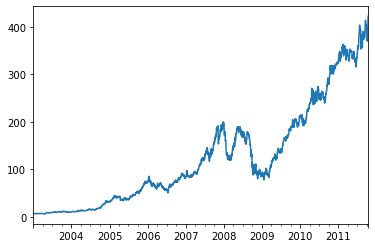

In [148]:
#rolling : Series나 DataFrame에 대해 원하는 기간을 나타내는 window값과 함께 호출 (resample과 groupby와 유사하게 작동)
close_px.AAPL.plot()

<AxesSubplot:>

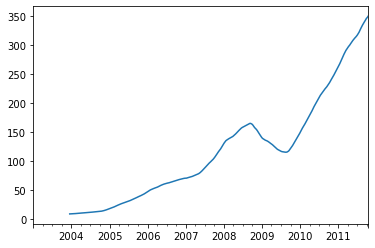

In [149]:
close_px.AAPL.rolling(250).mean().plot()
#resample(250) : 그룹을 생성하는 대신 250일 크기의 움직은 창을 통해 그룹핑할 수 있는 객체를 생성

In [150]:
appl_std250 = close_px.AAPL.rolling(250, min_periods= 10).std()
appl_std250[5:12]

2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15    0.077496
2003-01-16    0.074760
2003-01-17    0.112368
Freq: B, Name: AAPL, dtype: float64

<AxesSubplot:>

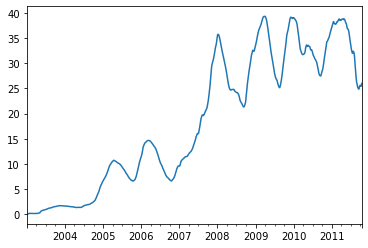

In [151]:
appl_std250.plot()

<AxesSubplot:>

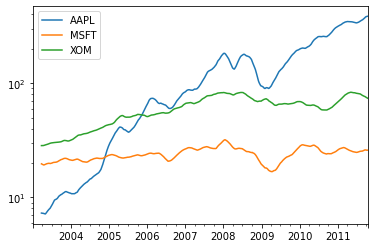

In [152]:
#확장창 평균 : 시계열의 시작 지점에서부터 창의 크기가 시계열의 전체 크기가 될 때까지 점점 창의 크기를 늘림 -> expanding
#시계열의 확장창 평균
expanding_mean = appl_std250.expanding().mean()
close_px.rolling(60).mean().plot(logy = True) #주가의 60일 이동평균(Y축 로그 스케일)
#이동평균 : 일정 범위에서 규칙적으로 연산

In [153]:
close_px.rolling('20D').mean() #고정 크기의 기간 지정 문자열을 넘겨서 호출

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


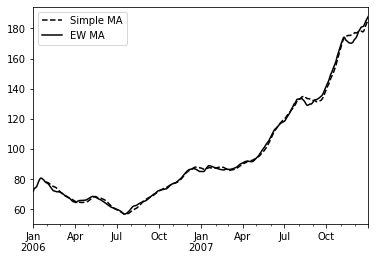

In [154]:
#균등한 가중치를 가지는 관찰과 함께 고정 크기 창을 사용 -> 감쇠인자(decay factor)상수에 좀 더 많은 가중치를 부여 
aapl_px = close_px.AAPL['2006':'2007']
ma60 = aapl_px.rolling(30, min_periods = 20).mean()
ewma60 = aapl_px.ewm(span = 30).mean()
ma60.plot(style = 'k--', label = 'Simple MA')
ewma60.plot(style = 'k-', label = 'EW MA')
import matplotlib.pyplot as plt
plt.legend()
#간단한 이동평균과 지수 가중 이동평균

In [155]:
#이진 이동창 함수 
spx_px = close_px_all['SPX']
spx_rets = spx_px.pct_change()
returns = close_px.pct_change() #pct_change() : 수익률 계산

<AxesSubplot:>

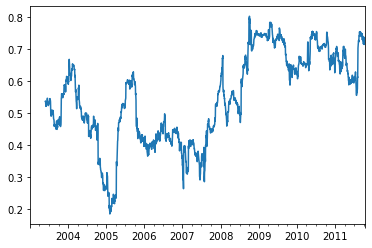

In [156]:
corr = returns.AAPL.rolling(125, min_periods= 100).corr(spx_rets)
corr.plot()
#6개월간 S&P 500 지수와 APPL 수익 상관관계

In [157]:
returns

,AAPL,MSFT,XOM
2003-01-02,NaN,NaN,NaN
2003-01-03,0.006757,0.001421,0.000684
2003-01-06,0.000000,0.017975,0.024624
2003-01-07,-0.002685,0.019052,-0.033712
2003-01-08,-0.020188,-0.028272,-0.004145
...,...,...,...
2011-10-10,0.051406,0.026286,0.036977
2011-10-11,0.029526,0.002227,-0.000131
2011-10-12,0.004747,-0.001481,0.011669
2011-10-13,0.015515,0.008160,-0.010238


<AxesSubplot:>

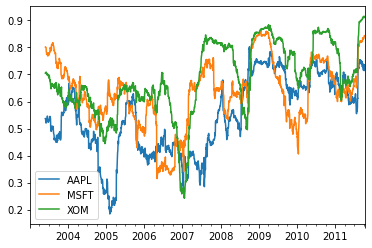

In [158]:
corr = returns.rolling(125, min_periods=100).corr(spx_rets)
corr.plot()